In [325]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

plt.rcParams["font.family"] = "serif"

In [326]:
dtype_to_bytes = {
    "float64": 8,
    "float32": 4,
    "float16": 2,
    "bfloat16": 2,
}

In [327]:
df = pd.read_csv("../results/benchmark_batched_gemv.csv")
df["times (ms)"] = df["times (ms)"].apply(ast.literal_eval)
df["time (ms)"] = df["times (ms)"].apply(min)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms)
0,33554432,2,float16,float32,custom,"[0.5397923278808594, 0.5133606338500977, 0.513...",3.592617e-04,0.512950
1,33554432,2,bfloat16,float32,custom,"[0.510984001159668, 0.5127036666870117, 0.5134...",3.591395e-04,0.510984
2,33554432,2,float16,float64,custom,"[0.8325023651123047, 0.8343385314941406, 0.834...",7.609187e-13,0.832502
3,33554432,2,bfloat16,float64,custom,"[0.7891481781005859, 0.7894367980957031, 0.789...",7.570934e-13,0.789148
4,14913080,3,float16,float32,custom,"[0.40641761779785157, 0.40727169036865235, 0.4...",4.145427e-04,0.406418
...,...,...,...,...,...,...,...,...
507,8192,128,bfloat16,float64,custom,"[0.2458095932006836, 0.233603515625, 0.2339302...",4.934779e-12,0.233604
508,8065,129,float16,float32,custom,"[0.20021055221557618, 0.18959392547607423, 0.1...",2.365060e-03,0.189594
509,8065,129,bfloat16,float32,custom,"[0.21051807403564454, 0.19763519287109374, 0.1...",2.362397e-03,0.197635
510,8065,129,float16,float64,custom,"[0.21287616729736328, 0.2037385559082031, 0.20...",4.957220e-12,0.203739


In [328]:
def throughput(n, k, time_ms, mat_dtype, vec_dtype):
    mat_el_bytes = dtype_to_bytes[mat_dtype]
    vec_el_bytes = dtype_to_bytes[vec_dtype]
    total_bytes = n * k * k * mat_el_bytes + n * k * vec_el_bytes + n * k * vec_el_bytes
    return total_bytes / (time_ms / 1000) / 1e9

In [329]:
def flops(n, k, time_ms):
    total_flops = 2 * n * k * k
    return total_flops / (time_ms / 1000) / 1e9

In [330]:
df["throughput"] = df.apply(
    lambda row: throughput(
        n=row["n"],
        k=row["k"],
        time_ms=row["time (ms)"],
        mat_dtype=row["A_dtype"],
        vec_dtype=row["b_dtype"],
    ),
    axis=1,
)
df["GFlops"] = df.apply(
    lambda row: flops(n=row["n"], k=row["k"], time_ms=row["time (ms)"]),
    axis=1,
)
df

,n,k,A_dtype,b_dtype,algorithm,times (ms),error norm,time (ms),throughput,GFlops
0,33554432,2,float16,float32,custom,"[0.5397923278808594, 0.5133606338500977, 0.513...",3.592617e-04,0.512950,1569.950711,523.316904
1,33554432,2,bfloat16,float32,custom,"[0.510984001159668, 0.5127036666870117, 0.5134...",3.591395e-04,0.510984,1575.991354,525.330451
2,33554432,2,float16,float64,custom,"[0.8325023651123047, 0.8343385314941406, 0.834...",7.609187e-13,0.832502,1612.220381,322.444076
3,33554432,2,bfloat16,float64,custom,"[0.7891481781005859, 0.7894367980957031, 0.789...",7.570934e-13,0.789148,1700.792471,340.158494
4,14913080,3,float16,float32,custom,"[0.40641761779785157, 0.40727169036865235, 0.4...",4.145427e-04,0.406418,1541.147166,660.491643
...,...,...,...,...,...,...,...,...,...,...
507,8192,128,bfloat16,float64,custom,"[0.2458095932006836, 0.233603515625, 0.2339302...",4.934779e-12,0.233604,1220.926283,1149.107090
508,8065,129,float16,float32,custom,"[0.20021055221557618, 0.18959392547607423, 0.1...",2.365060e-03,0.189594,1459.658633,1415.759125
509,8065,129,bfloat16,float32,custom,"[0.21051807403564454, 0.19763519287109374, 0.1...",2.362397e-03,0.197635,1400.268879,1358.155529
510,8065,129,float16,float64,custom,"[0.21287616729736328, 0.2037385559082031, 0.20...",4.957220e-12,0.203739,1399.173017,1317.469483


In [333]:
def plot_throughput(ax, mat_dtype: str, vec_dtype: str, labels: bool = False):
    max_tput = df[
        (df.A_dtype == mat_dtype) & (df.b_dtype == vec_dtype) & (df.k <= 128)
    ].pivot_table(values="throughput", columns="algorithm", index="k", aggfunc="max")

    title = f"{mat_dtype} $\\times$ {vec_dtype}"
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel("matrix size k")
    ax.set_ylabel("throughput (GB/s)")

    ax.set_xlim(left=0, right=130)
    ax.set_ylim(bottom=0, top=2140)

    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey")

    ax.scatter(
        x=max_tput.index,
        y=max_tput["custom"],
        marker="^",
        label="Our implementation" if labels else None,
        s=13,
        zorder=3,
        facecolors="none",
        edgecolors="tab:blue",
    )
    # ax.scatter(
    #     x=max_tput.index,
    #     y=max_tput["torch"],
    #     marker="o",
    #     label="PyTorch" if labels else None,
    #     s=13,
    #     zorder=2,
    #     facecolors="none",
    #     edgecolors="tab:orange",
    # )
    ax.axhline(
        y=2039,
        color="red",
        linestyle="--",
        label="A100 bandwidth (2,039GB/s)" if labels else None,
    )

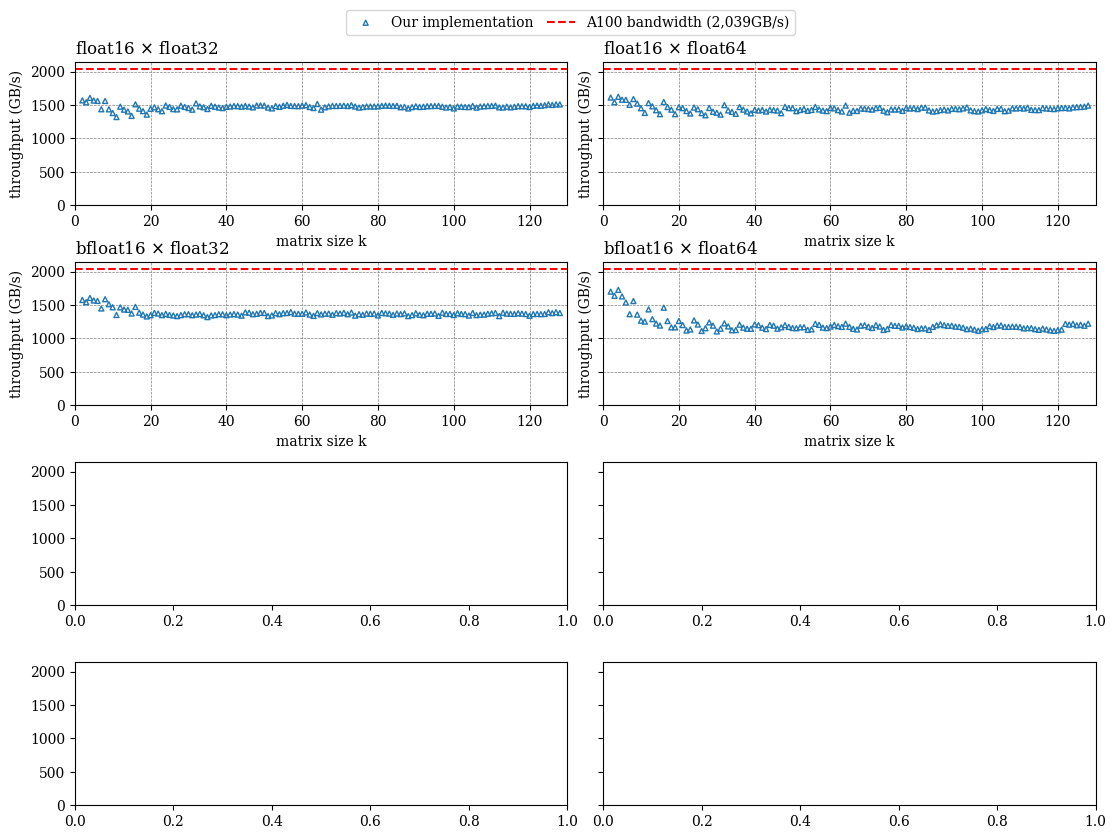

In [334]:
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharey=True)
fig.tight_layout(pad=1.0, h_pad=2.0)
for i, mat_dtype in enumerate(df.A_dtype.unique()):
    for j, vec_dtype in enumerate(df.b_dtype.unique()):
        if mat_dtype == "float64" and vec_dtype == "float32":
            continue
        plot_throughput(axes[i, j], mat_dtype, vec_dtype, labels=(i == 0 and j == 0))

fig.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.05), columnspacing=1)
# fig.savefig("../docs/thesis-media/matrix_vec_tput.svg", bbox_inches="tight")

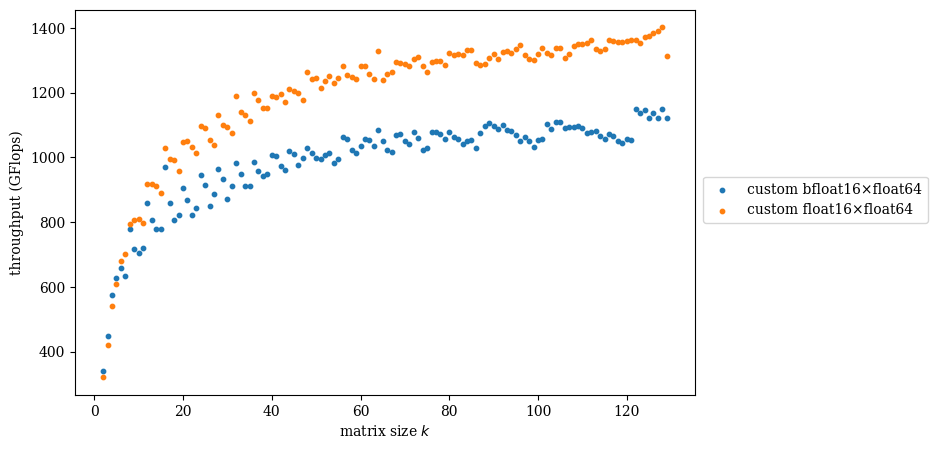

In [ ]:
max_tput = df.pivot_table(
    values="GFlops",
    columns=["algorithm", "A_dtype", "b_dtype"],
    index="k",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel("matrix size $k$")
ax.set_ylabel("throughput (GFlops)")

for col in max_tput.columns:
    if col[2] == "float64" and col[0] == "custom":
        ax.scatter(
            max_tput.index,
            max_tput[col],
            label=col[0] + " " + col[1] + "×" + col[2],
            s=10,
        )

fig.legend(loc="right", bbox_to_anchor=(1.2, 0.5))